## CFAR Ship Detection

ESA SNAP 
- https://step.esa.int/main/wp-content/help/versions/9.0.0/snap-toolboxes/org.esa.s1tbx.s1tbx.op.feature.extraction.ui/operators/ObjectDetection.html

 D. J. Crisp, "The State-of-the-Art in Ship Detection in Synthetic Aperture Radar Imagery." DSTO–RR–0272, 2004-05.
- https://apps.dtic.mil/sti/tr/pdf/ADA426096.pdf

In [8]:
import os
import numpy as np
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt


PATH_OUTPUT = os.path.join('output', f'407')
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [2]:
import cv2
import numpy as np

class CFAR:
    def __init__(self, background_size, guard_size, pixel_size, threshold_value):
        self.background_size = background_size
        self.guard_size = guard_size
        self.pixel_size = pixel_size
        self.threshold_value = threshold_value

    def get_edge_offset(self, i, window_size, limit):
        min_index = i - window_size // 2
        max_index = i + window_size // 2
        if min_index > 0 and max_index < limit:
            return 0
        else:
            if min_index < 0:
                return -min_index
            else:
                return limit - max_index - 1

    def get_block_sum(self, input_image, i, j, block_size):
        total_pixels = 0
        block_sum = 0
        rows, cols = input_image.shape
        offset_x = self.offset_x
        offset_y = self.offset_y

        for x in range(-block_size // 2, block_size // 2 + 1):
            for y in range(-block_size // 2, block_size // 2 + 1):
                r = i + y + offset_x
                c = j + x + offset_y
                if 0 <= r < rows and 0 <= c < cols:
                    total_pixels += 1
                    block_sum += int(input_image[r, c])

        return block_sum, total_pixels

    def inference(self, input_image):
        output_image = np.zeros_like(input_image, dtype=np.uint8)
        rows, cols = input_image.shape

        for i in range(rows):
            for j in range(cols):
                pixel = int(input_image[i, j])

                # MINIMUM_PIXEL_VALUEに対応
                if pixel < 1:  # 適切な値に調整
                    output_image[i, j] = 0
                    continue

                # Calculate CUT average
                if self.pixel_size < 2:
                    cut_avg = pixel
                else:
                    self.offset_x = 0
                    self.offset_y = 0
                    cut_sum, total_pixels = self.get_block_sum(input_image, i, j, self.pixel_size)
                    cut_avg = cut_sum / total_pixels

                # Calculate background and guard sums
                self.offset_x = self.get_edge_offset(i, self.background_size, rows)
                self.offset_y = self.get_edge_offset(j, self.background_size, cols)
                bg_sum, bg_pixels = self.get_block_sum(input_image, i, j, self.background_size)

                self.offset_x = self.get_edge_offset(i, self.guard_size, rows)
                self.offset_y = self.get_edge_offset(j, self.guard_size, cols)
                guard_sum, guard_pixels = self.get_block_sum(input_image, i, j, self.guard_size)

                # Calculate background average excluding guard region
                if bg_pixels - guard_pixels > 0:
                    bg_avg = (bg_sum - guard_sum) / (bg_pixels - guard_pixels)
                else:
                    bg_avg = 0  # Avoid division by zero

                # Apply CFAR threshold
                if cut_avg > self.threshold_value * bg_avg:
                    output_image[i, j] = 255
                else:
                    output_image[i, j] = 0

        return output_image


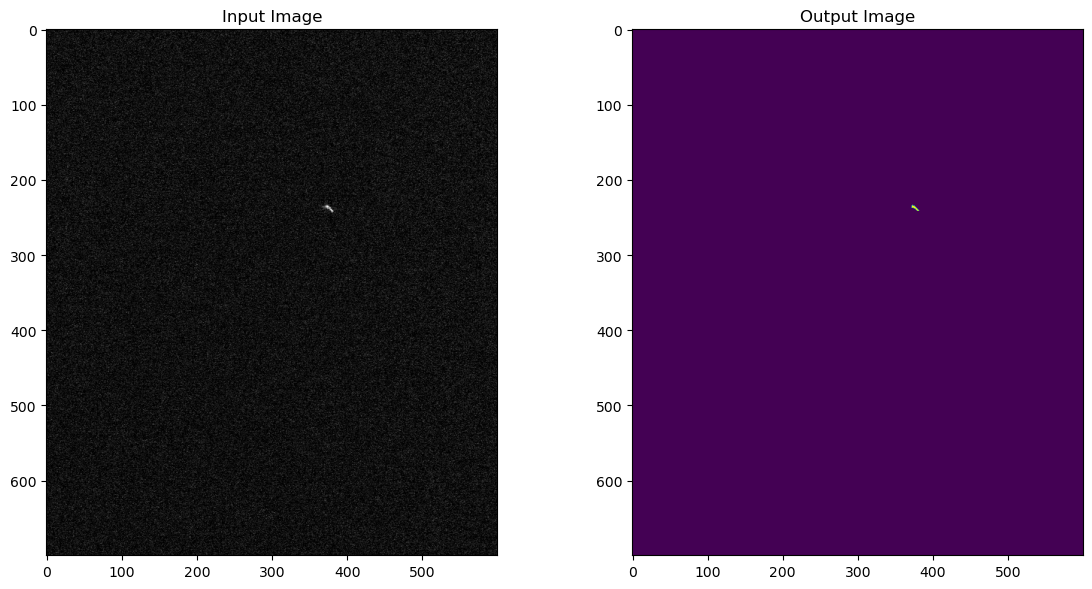

In [3]:
input_image = cv2.imread("700_ship.png", cv2.IMREAD_GRAYSCALE)
background_size = 14  # 背景領域のサイズ
guard_size = 4        # ガード領域のサイズ
pixel_size = 4        # ピクセルのブロックサイズ
threshold_value = 2.5 # 閾値のスケール係数

cfar = CFAR(background_size, guard_size, pixel_size, threshold_value)
output_image = cfar.inference(input_image)

# plot 
plt.figure(figsize=(12, 6), facecolor='w' , edgecolor='k', dpi=100)
plt.subplot(1, 2, 1)
plt.imshow(input_image, cmap='gray')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.imshow(output_image,)
plt.title('Output Image')
plt.tight_layout()

plt.savefig(os.path.join(PATH_OUTPUT, 'cfar_compare.png'))
plt.show();plt.clf();plt.close()


Ship center coordinates: [238 376]


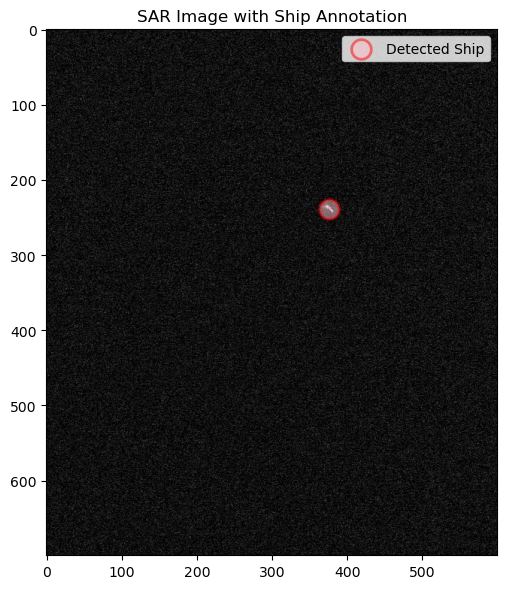

In [4]:
detected_pixels = np.column_stack(np.where(output_image == 255))

pixel_ship_center = np.mean(detected_pixels, axis=0)
pixel_ship_center = np.round(pixel_ship_center, decimals=0).astype(int)
print(f"Ship center coordinates: {pixel_ship_center}")

# plot the coordinates
plt.figure(figsize=(10, 6), facecolor='w' , edgecolor='k', dpi=100)
plt.imshow(input_image, cmap='gray')
plt.scatter(pixel_ship_center[1], pixel_ship_center[0], c="pink", alpha=0.5, linewidths=2,
            edgecolors="red", s=200, label="Detected Ship")
plt.title('SAR Image with Ship Annotation')
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(PATH_OUTPUT, 'cfar_detected.png'))
plt.show();plt.clf();plt.close()

100%|██████████| 3/3 [01:41<00:00, 33.96s/it]


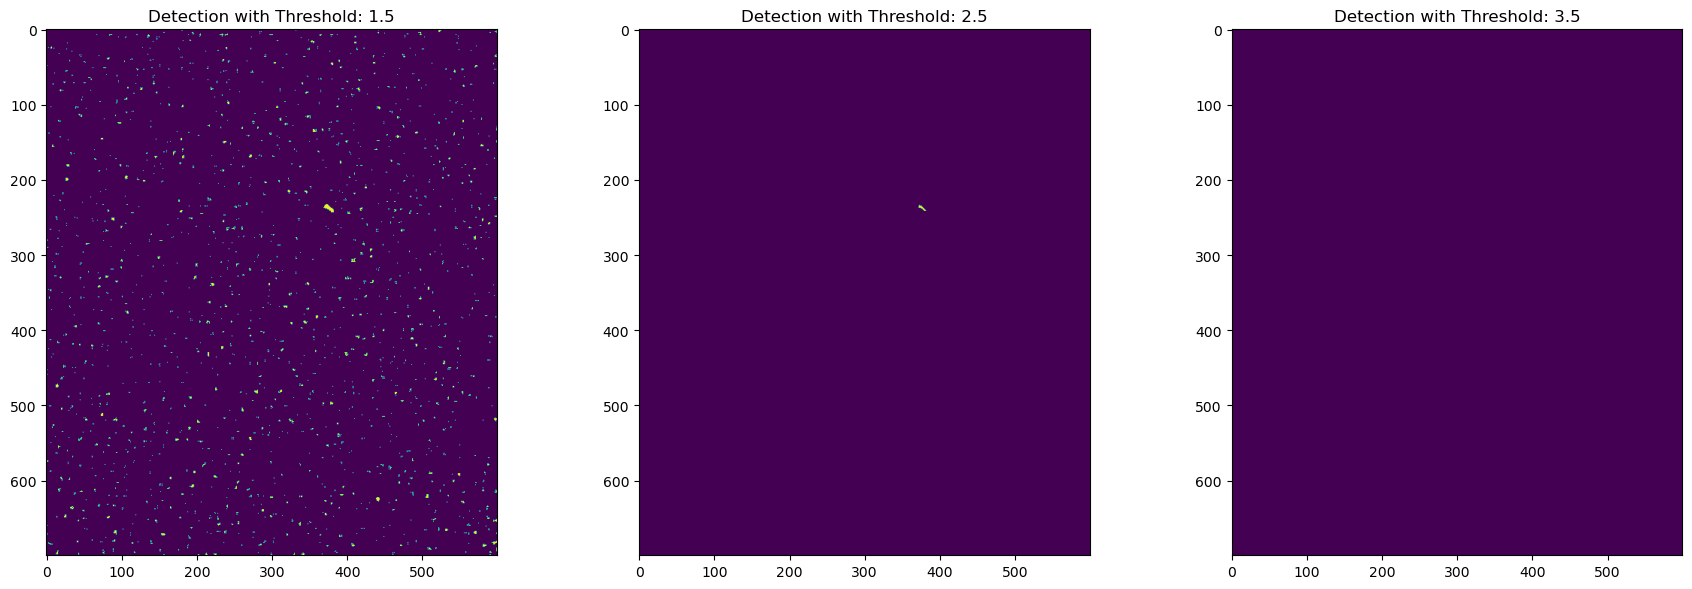

In [9]:
threshold_values = [1.5, 2.5 ,3.5]

# plot 
plt.figure(figsize=(18, 6), facecolor='w' , edgecolor='k', dpi=100)
for i, _v in tqdm(enumerate(threshold_values), total=len(threshold_values)):
    cfar = CFAR(background_size, guard_size, pixel_size, _v)
    output_image = cfar.inference(input_image)
    plt.subplot(1, 3, i+1)
    plt.imshow(output_image,)
    plt.title('Detection with Threshold: %.1f' % _v)
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'cfar_with_thresholds.png'))
plt.show();plt.clf();plt.close()
